# Spectral Transform Pipeline 可视化验证

数据源: `code/delta_learn/tst/AU.feather` (AU 黄金 1 天 tick 数据)

验证内容:
1. 原始 13 维特征计算 + log 变换
2. 7 个平稳通道选择与时序可视化
3. SpectralTransformer 完整 pipeline
4. Filterbank 可视化
5. 频谱热力图 (时间 × 频率)
6. 输出分布统计
7. 因果性验证
8. 与 FactorCalculator 输出对比
9. 性能 Benchmark
10. Power vs Amplitude Spectrum 对比
11. 为什么 Power Spectrum 失败 — 量化分析
12. 加长 n_fft 能不能替代 amplitude
13. 标准化方案对比 (Log only vs Fixed z-score vs Rolling z-score)
14. 最终 Pipeline 与设计决策总结

In [17]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['figure.dpi'] = 120

# delta_learn project root
PROJECT_ROOT = '../code/delta_learn'
sys.path.insert(0, PROJECT_ROOT)

## 1. 从原始 tick 计算 13 维特征

复现 `FuturesStore.load_tick_features()` 的计算逻辑, 无需 SQL 连接。

In [18]:
# 加载原始 tick 数据
raw_df = pd.read_feather(f'{PROJECT_ROOT}/tst/AU.feather')
print(f'Shape: {raw_df.shape}')
print(f'Time range: {raw_df["Datetime"].iloc[0]} ~ {raw_df["Datetime"].iloc[-1]}')
raw_df.head(3)

Shape: (56354, 24)
Time range: 2023-11-30 20:59:00.500 ~ 2023-12-01 15:00:00.500


,Datetime,TradingDay,InstrumentID,ContractId,OpenPrice,LastPrice,HighPrice,LowPrice,OpenInterest,Turnover,...,LowerLimitPrice,AskPrice1,AskPrice2,AskVolume1,AskVolume2,BidPrice1,BidPrice2,BidVolume1,BidVolume2,ContractMultiplier
0,2023-11-30 20:59:00.500,2023-12-01,AU2402,AU,475.4,475.4,475.4,475.40,203364.0,34704200.0,...,447.12,475.42,475.44,8.0,52.0,475.4,475.30,2.0,1.0,1000.0
1,2023-11-30 21:00:00.500,2023-12-01,AU2402,AU,475.4,475.3,475.4,475.20,203389.0,53241180.0,...,447.12,475.28,475.30,1.0,1.0,475.2,475.18,1.0,7.0,1000.0
2,2023-11-30 21:00:01.000,2023-12-01,AU2402,AU,475.4,475.2,475.4,475.16,203397.0,79853820.0,...,447.12,475.22,475.24,1.0,2.0,475.2,475.18,1.0,2.0,1000.0


In [19]:
# 计算 13 维特征 (复现 FuturesStore.load_tick_features)
df = raw_df.copy()

bid = df['BidPrice1']
ask = df['AskPrice1']
bid_vol = df['BidVolume1']
ask_vol = df['AskVolume1']
mid = (bid + ask) / 2.0
multiplier = df['ContractMultiplier'].replace(0, np.nan)

df['mid_price'] = mid
df['vwap'] = df['Turnover'] / (df['Volume'] * multiplier).replace(0, np.nan)
df['micro_price'] = (bid * ask_vol + ask * bid_vol) / (bid_vol + ask_vol).replace(0, np.nan)

# Log returns (shift 1)
for col, lr_col in [
    ('mid_price', 'mid_price_lr_s1'),
    ('LastPrice', 'last_price_lr_s1'),
    ('vwap', 'vwap_lr_s1'),
    ('micro_price', 'micro_price_lr_s1'),
]:
    prev = df[col].shift(1)
    df[lr_col] = np.log(df[col] / prev.replace(0, np.nan))

df['vol_diff'] = df['Volume'].diff()

df['obi_1'] = (df['BidVolume1'] - df['AskVolume1']) / \
              (df['BidVolume1'] + df['AskVolume1']).replace(0, np.nan)
df['spread_1'] = (ask - bid) / mid.replace(0, np.nan)

df.rename(columns={'OpenInterest': 'OpenInterest_raw'}, inplace=True)
df['OpenInterest'] = df['OpenInterest_raw']

# 第一行 diff/lr 填 0
lr_cols = ['mid_price_lr_s1', 'last_price_lr_s1', 'vwap_lr_s1', 'micro_price_lr_s1', 'vol_diff']
df.iloc[0, df.columns.get_indexer(lr_cols)] = 0.0
df = df.ffill().fillna(0)

# 13 维特征列
FEATURE_COLS = [
    'mid_price', 'vwap', 'micro_price',
    'mid_price_lr_s1', 'last_price_lr_s1', 'vwap_lr_s1', 'micro_price_lr_s1',
    'vol_diff', 'AskVolume1', 'BidVolume1',
    'obi_1', 'spread_1', 'OpenInterest',
]

features_raw = df[FEATURE_COLS].values.astype(np.float32)
returns = df['mid_price_lr_s1'].values.astype(np.float32)

# Log 变换 (与 precompute 一致)
LOG_TRANSFORM_INDICES = [7, 8, 9, 12]  # vol_diff, AskVolume1, BidVolume1, OpenInterest
features = features_raw.copy()
for idx in LOG_TRANSFORM_INDICES:
    col = features[:, idx]
    features[:, idx] = np.sign(col) * np.log1p(np.abs(col))
np.nan_to_num(features, copy=False, nan=0.0, posinf=0.0, neginf=0.0)

print(f'Features shape: {features.shape}')
print(f'Returns shape: {returns.shape}')
print(f'NaN in features: {np.isnan(features).sum()}')
print(f'NaN in returns: {np.isnan(returns).sum()}')

Features shape: (56354, 13)
Returns shape: (56354,)
NaN in features: 0
NaN in returns: 0


## 2. 7 个平稳通道: 时序可视化

选取的通道: `[3,4,5,6,7,10,11]`
- 4 个收益率: mid_price_lr_s1, last_price_lr_s1, vwap_lr_s1, micro_price_lr_s1
- vol_diff (log): 成交量变化
- obi_1: 盘口不平衡 [-1, 1]
- spread_1: 价差比 [0, ~0.01]

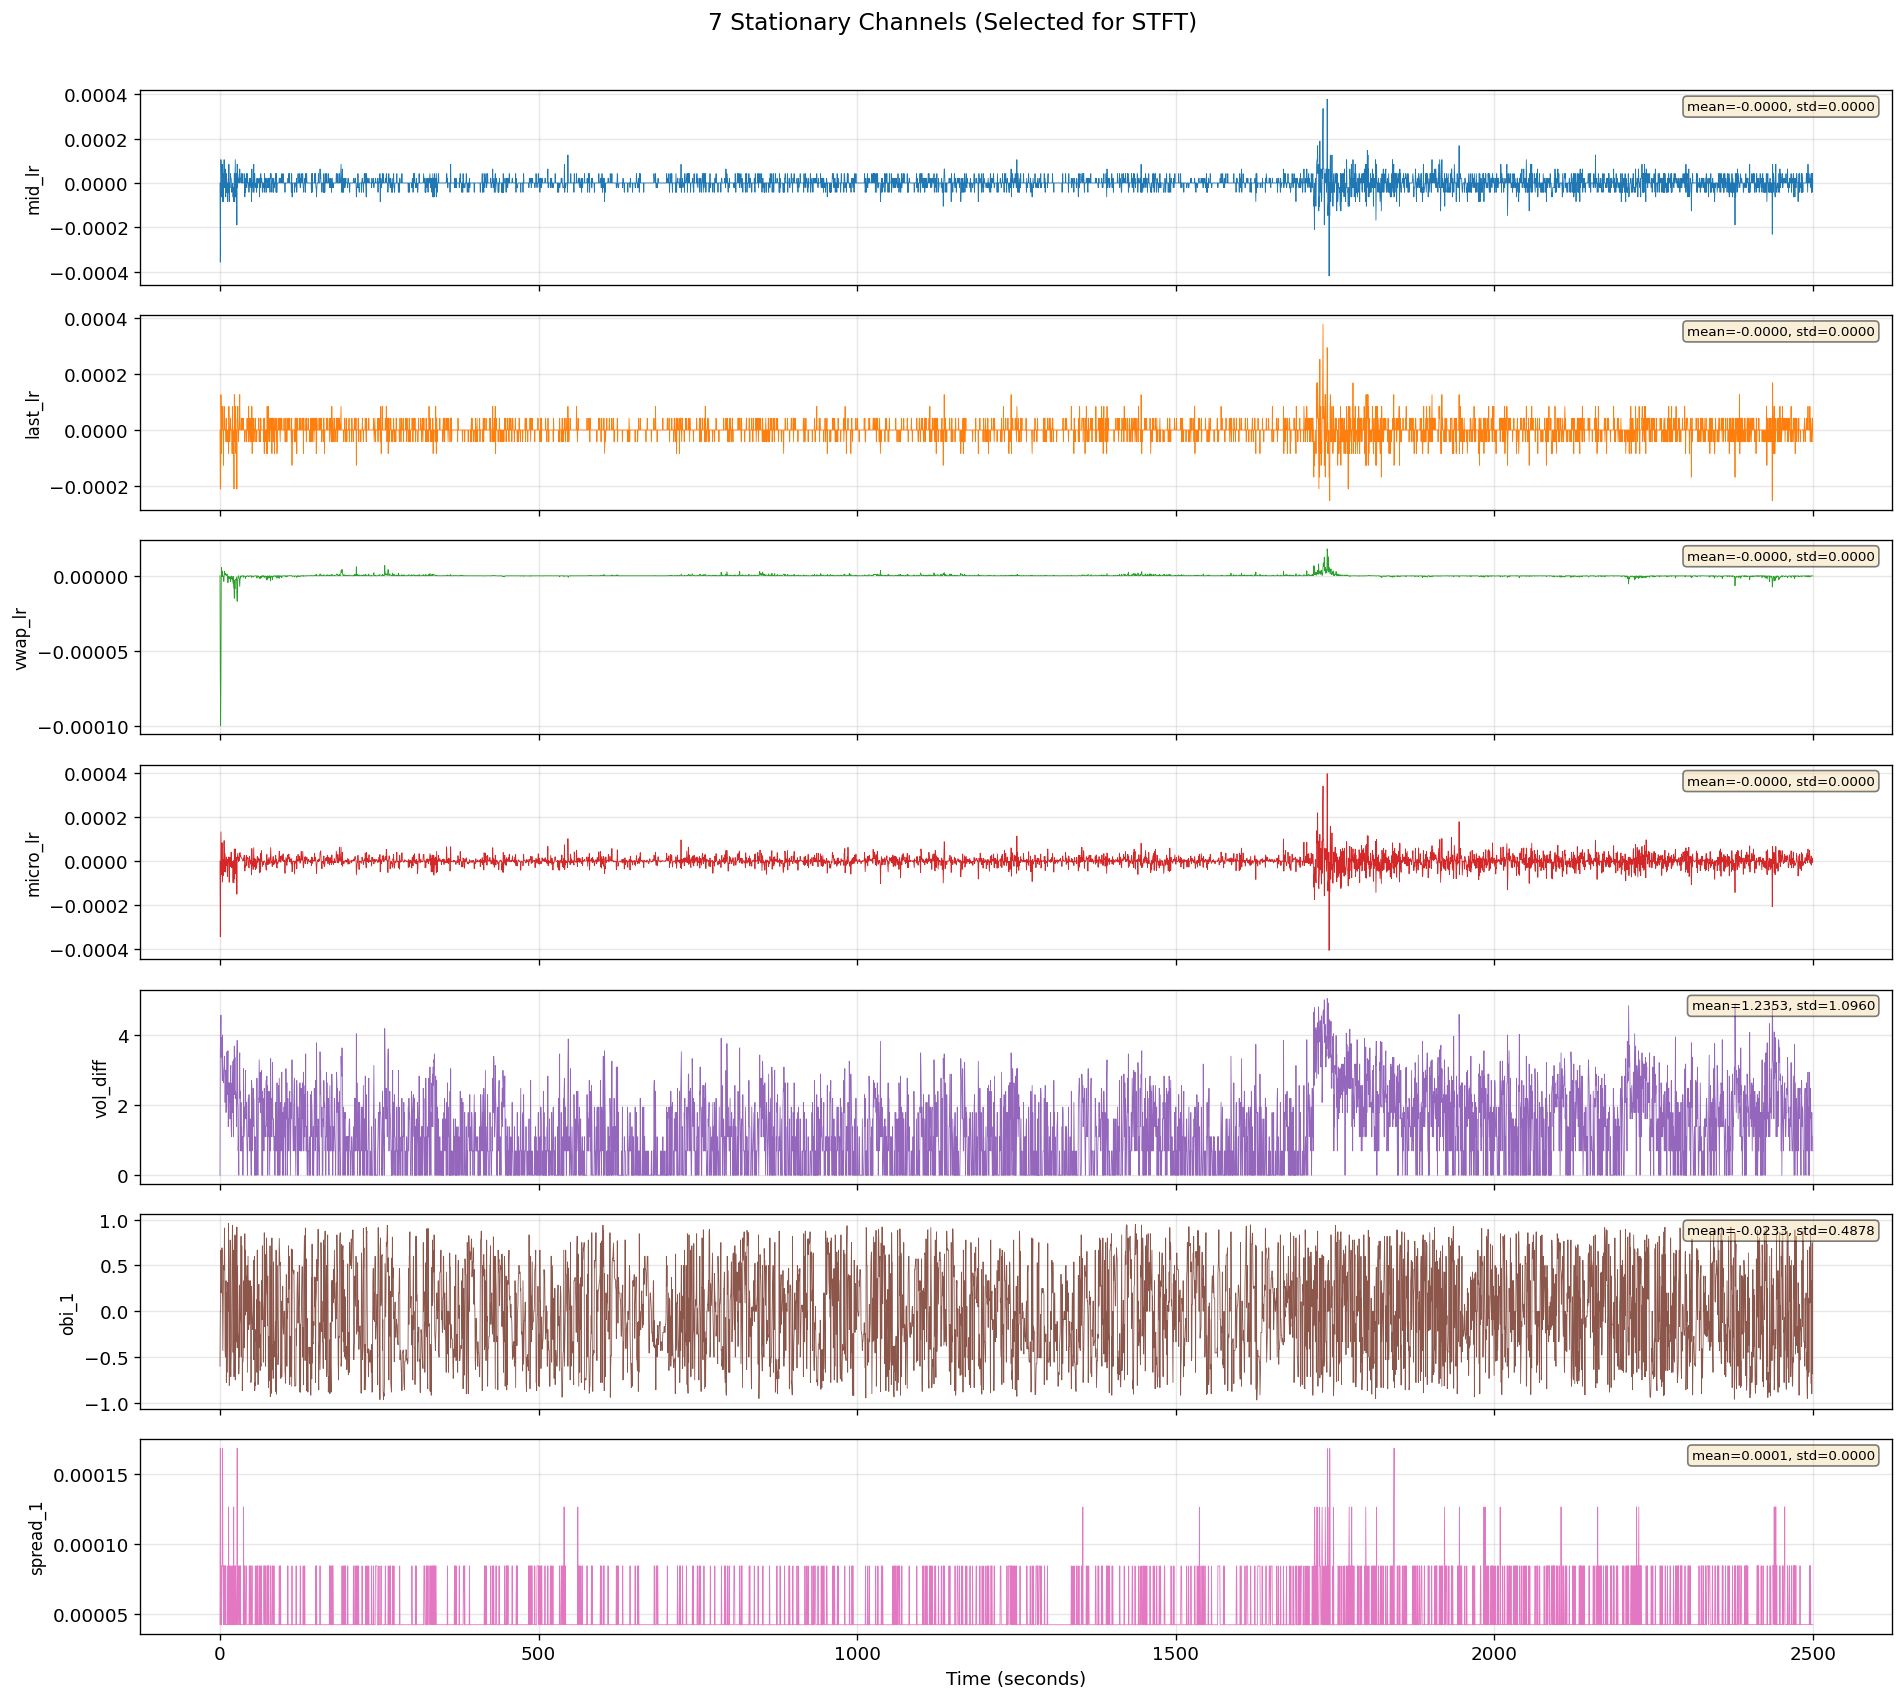

In [20]:
CHANNEL_INDICES = [3, 4, 5, 6, 7, 10, 11]
CHANNEL_NAMES = ['mid_lr', 'last_lr', 'vwap_lr', 'micro_lr', 'vol_diff', 'obi_1', 'spread_1']

# 非平稳通道 (不用于 STFT)
NON_STATIONARY = [0, 1, 2, 8, 9, 12]
NON_STAT_NAMES = ['mid_price', 'vwap', 'micro_price', 'AskVol1', 'BidVol1', 'OpenInterest']

fig, axes = plt.subplots(7, 1, figsize=(16, 14), sharex=True)
fig.suptitle('7 Stationary Channels (Selected for STFT)', fontsize=14, y=1.01)

# 只显示前 5000 ticks (~42 min) 以便观察细节
N_SHOW = 5000
t = np.arange(N_SHOW) / 2  # seconds

for i, (ch_idx, name) in enumerate(zip(CHANNEL_INDICES, CHANNEL_NAMES)):
    ax = axes[i]
    data = features[:N_SHOW, ch_idx]
    ax.plot(t, data, linewidth=0.5, color=f'C{i}')
    ax.set_ylabel(name, fontsize=10)
    ax.grid(True, alpha=0.3)
    # 标注统计
    ax.text(0.99, 0.95, f'mean={data.mean():.4f}, std={data.std():.4f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[-1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()

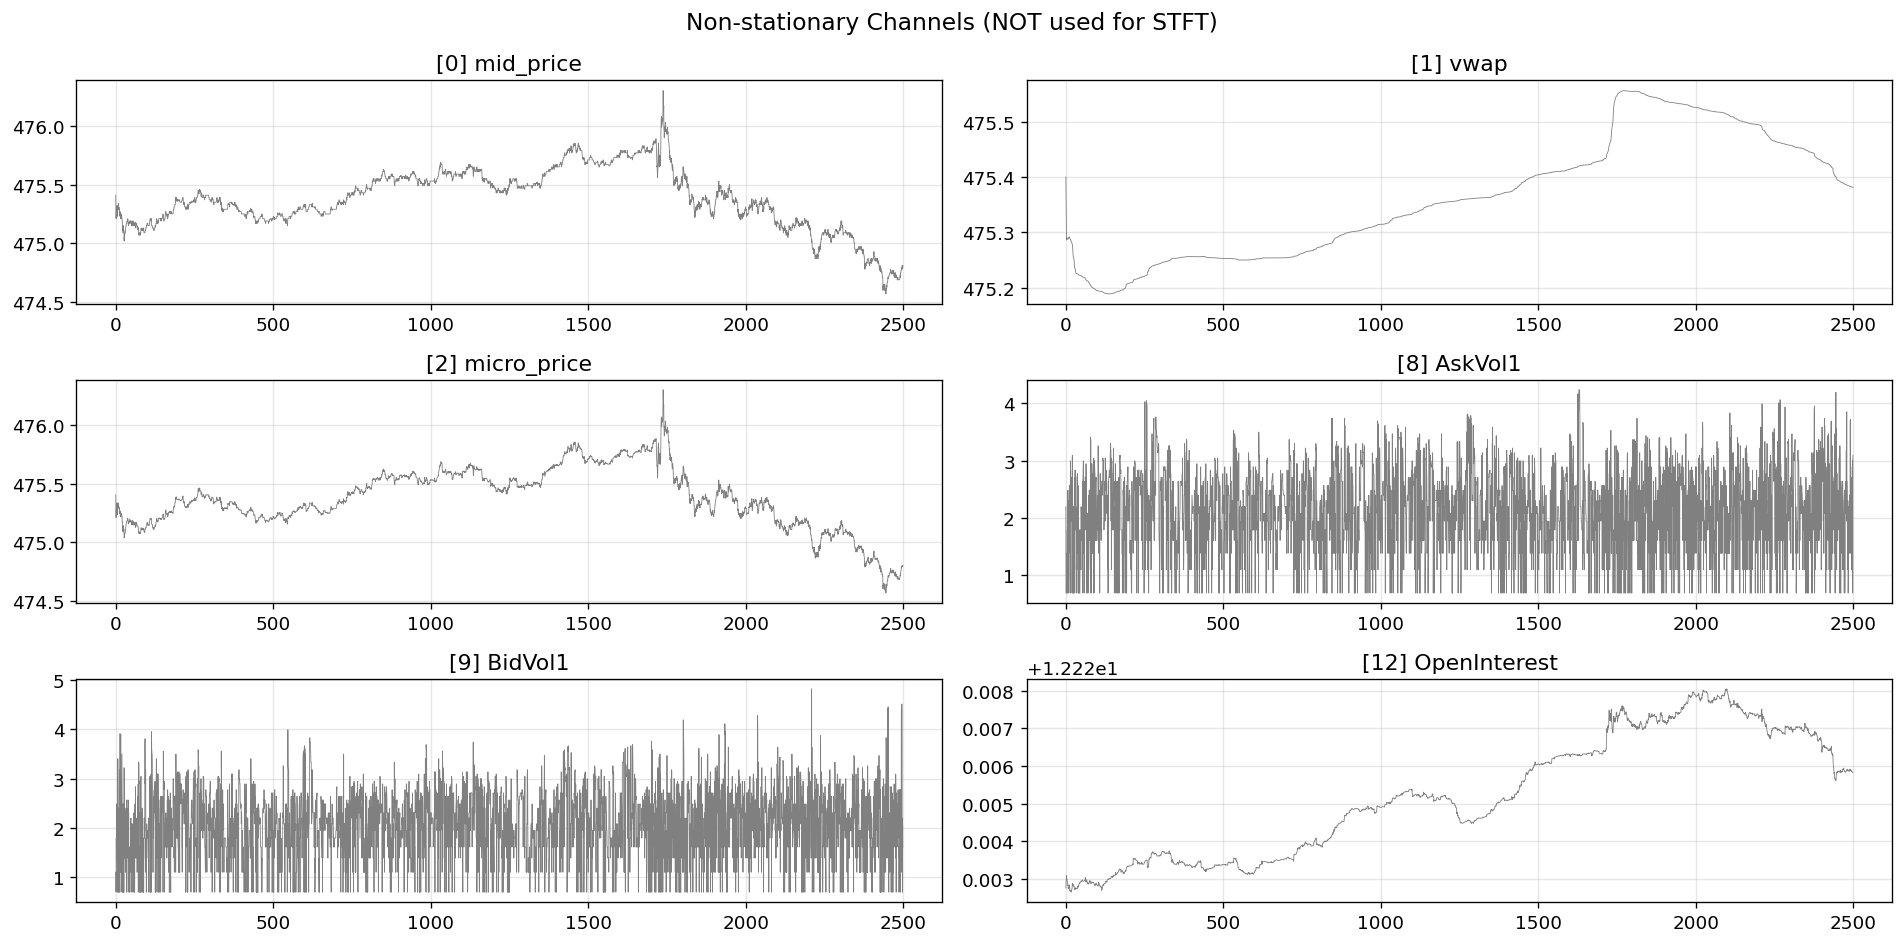

In [21]:
# 对比: 非平稳通道 (不用于 STFT 的原因)
fig, axes = plt.subplots(3, 2, figsize=(16, 8))
fig.suptitle('Non-stationary Channels (NOT used for STFT)', fontsize=14)

for i, (ch_idx, name) in enumerate(zip(NON_STATIONARY, NON_STAT_NAMES)):
    ax = axes.flat[i]
    data = features[:N_SHOW, ch_idx]
    ax.plot(t, data, linewidth=0.5, color='gray')
    ax.set_title(f'[{ch_idx}] {name}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. SpectralTransformer Pipeline

核心思路: 把金融 tick 特征当作 **多通道音频信号**, 用 STFT + Log-Filterbank 提取频谱特征。

### 输入 → 输出

```
输入: raw ticks (N, 13)  — 一天 ~50,000 ticks, 13 维原始特征
输出: (n_patches, 112)   — 每 patch 一个 112 维频谱向量 (7 通道 × 16 频段)
```

### 逐步计算过程

**Step 1 — 通道选择**: 从 13 维中选 7 个平稳通道 (indices [3,4,5,6,7,10,11])
```
(N, 13) → (N, 7)
```
只选平稳信号 (收益率、成交量差、盘口不平衡、价差比)。
非平稳信号 (价格、持仓量) 的 STFT 被 DC 分量 (均值) 淹没, 无法看到有用频率成分。

**Step 2 — 因果 STFT 窗口构建**: 每个 patch 对应一个 120-tick (60s) 的窗口
```
                  ┌─── n_fft=120 ticks (60s) ───┐
patch_0:  [zero-pad 60] [patch_0 的 60 ticks]     ← 左侧零填充 (warmup)
patch_1:  [patch_0 的 60 ticks] [patch_1 的 60 ticks]  ← 因果: 只看当前 + 前 1 个 patch
patch_k:  [patch_{k-1}] [patch_k]
```
- hop = patch_size = 60 ticks → 每 patch 恰好一个频谱帧, 与 FactorCalculator 对齐
- n_fft = 120 > patch_size = 60: 加长窗口获得 61 个真实频率 bin (而非 31 个)
- **严格因果**: 窗口只包含当前 patch 和前一个 patch 的数据

**Step 3 — Hann 窗**: 给每个 120-tick 窗口乘 Hann 窗函数
```
windowed = window × hann(120)     — 抑制窗口边缘的频谱泄漏
```

**Step 4 — FFT + 取幅度**: 对加窗信号做实数 FFT, 取幅度 (不取平方)
```
spectrum = rfft(windowed)          — (P, 61, 7) complex
amplitude = |spectrum|             — (P, 61, 7) real
```
为什么取幅度而非功率 (|FFT|²)?
→ 功率对弱信号做了两次压缩 (平方 + log), 导致收益率通道的值被压到 log_eps 下限 (全黑)。
  幅度只做一次压缩 (log), 保留了可区分的频率结构。详见 Section 10-11。

**Step 5 — Log-Filterbank 聚合**: 16 个三角滤波器将 61 个频率 bin 聚合为 16 个频段
```
filterbank: (16, 61)   — log-period 尺度, 低频分辨率高, 高频压缩
band_energy = amplitude @ filterbank.T    — (P, 7, 16)
```
类似音频的 Mel filterbank, 但用 log-period 尺度: 长周期 (低频) 保留最大分辨率。

**Step 6 — Log 压缩**: 压缩动态范围
```
log_mel = log(max(band_energy, 1e-6))
```
只做 log, **不做额外归一化** — 避免引入 look-ahead bias。

**Step 7 — Reshape**: 7 通道 × 16 频段 → 展平为 112 维向量
```
output = log_mel.reshape(P, 7 × 16)    — (P, 112)
```

### 参数总结

| 参数 | 值 | 含义 |
|------|-----|------|
| patch_size | 60 ticks (30s) | 每 patch 时长, = hop size |
| n_fft | 120 ticks (60s) | STFT 窗口长度, = 2 × patch |
| n_freq | 61 | 频率 bin 数 (= n_fft/2 + 1) |
| n_bands | 16 | filterbank 滤波器数 |
| n_channels | 7 | 平稳通道数 |
| n_factors | 112 | 输出维度 (= 7 × 16) |
| fs | 2 Hz | 采样率 (500ms/tick) |
| freq_resolution | 0.0167 Hz | 可分辨最小频率差 (= fs/n_fft) |

In [22]:
# 直接导入 (绕过 data/__init__.py 的 delta_data 依赖)
import importlib.util
spec = importlib.util.spec_from_file_location(
    'spectral_transform',
    f'{PROJECT_ROOT}/data/spectral_transform.py'
)
st_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(st_mod)

SpectralTransformer = st_mod.SpectralTransformer
build_log_filterbank = st_mod.build_log_filterbank

# 创建 transformer
transformer = SpectralTransformer(patch_size=60, n_fft=120, n_bands=16)

# 运行
spectral_output = transformer.transform(features)
n_patches = spectral_output.shape[0]

print(f'Input:  ({features.shape[0]}, {features.shape[1]})  — {features.shape[0]} ticks, 13 features')
print(f'Output: {spectral_output.shape}  — {n_patches} patches, {transformer.n_factors} factors')
print(f'Patch duration: {transformer.patch_size / 2:.0f}s (= {transformer.patch_size} ticks @ 2Hz)')
print(f'STFT window: {transformer.n_fft / 2:.0f}s (= {transformer.n_fft} ticks, causal)')
print(f'\nOutput stats:')
print(f'  mean={spectral_output.mean():.4f}, std={spectral_output.std():.4f}')
print(f'  min={spectral_output.min():.4f}, max={spectral_output.max():.4f}')
print(f'  NaN={np.isnan(spectral_output).sum()}, Inf={np.isinf(spectral_output).sum()}')

Input:  (56354, 13)  — 56354 ticks, 13 features
Output: (939, 112)  — 939 patches, 112 factors
Patch duration: 30s (= 60 ticks @ 2Hz)
STFT window: 60s (= 120 ticks, causal)

Output stats:
  mean=-6.6830, std=5.5192
  min=-13.8155, max=3.9289
  NaN=0, Inf=0


## 4. Filterbank 可视化

/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_7542/3195664908.py:3: RuntimeWarning: divide by zero encountered in divide
  periods = np.where(freq_bins > 0, 1.0 / freq_bins, np.inf)  # seconds


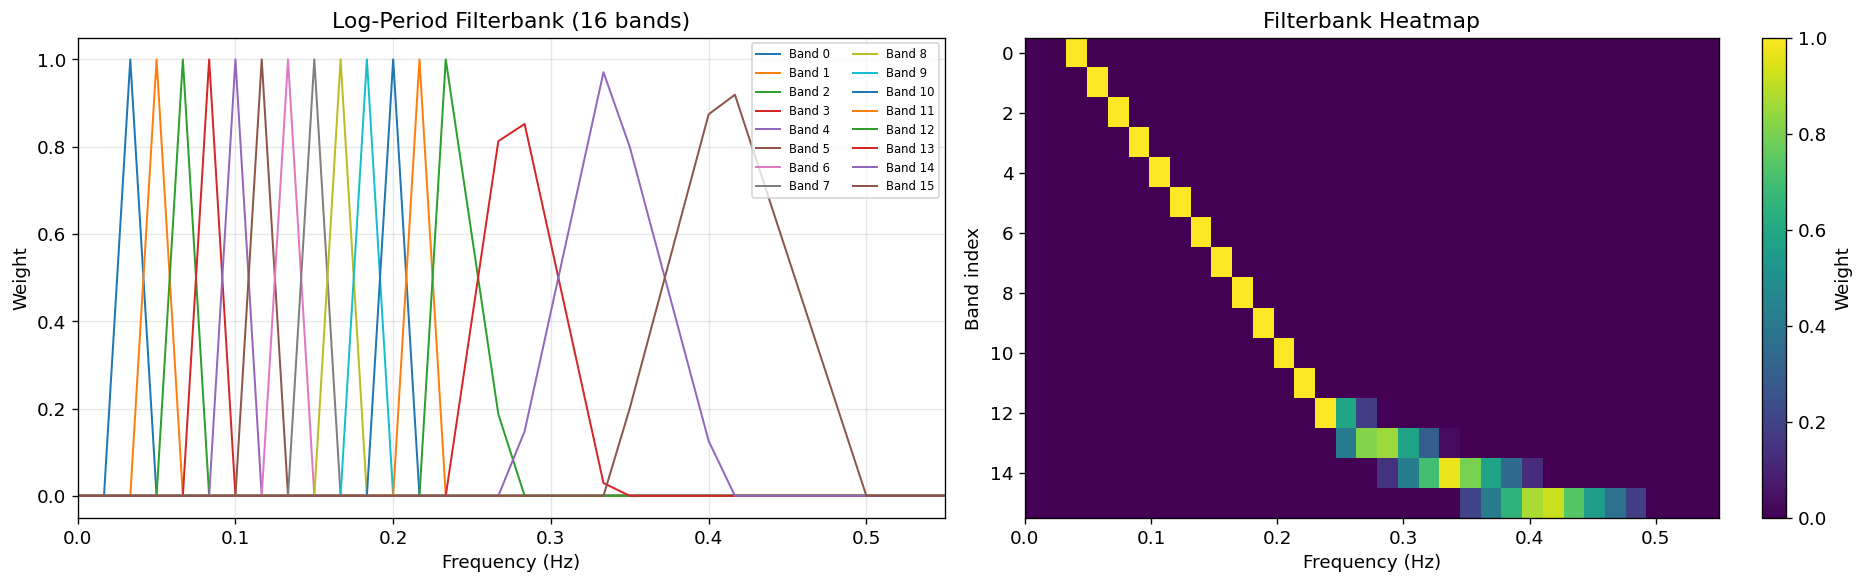

Band coverage:
 Band       Bins       Freq (Hz)      Period (s)   Peak
    0   2-2     0.0333-0.0333    30.0-30.0s     1.00
    1   3-3     0.0500-0.0500    20.0-20.0s     1.00
    2   4-4     0.0667-0.0667    15.0-15.0s     1.00
    3   5-5     0.0833-0.0833    12.0-12.0s     1.00
    4   6-6     0.1000-0.1000    10.0-10.0s     1.00
    5   7-7     0.1167-0.1167    8.6-8.6s     1.00
    6   8-8     0.1333-0.1333    7.5-7.5s     1.00
    7   9-9     0.1500-0.1500    6.7-6.7s     1.00
    8  10-10    0.1667-0.1667    6.0-6.0s     1.00
    9  11-11    0.1833-0.1833    5.5-5.5s     1.00
   10  12-12    0.2000-0.2000    5.0-5.0s     1.00
   11  13-13    0.2167-0.2167    4.6-4.6s     1.00
   12  14-16    0.2333-0.2667    4.3-3.8s     1.00
   13  15-20    0.2500-0.3333    4.0-3.0s     0.85
   14  17-24    0.2833-0.4000    3.5-2.5s     0.97
   15  21-29    0.3500-0.4833    2.9-2.1s     0.92


In [23]:
fb = transformer._filterbank  # (16, 61)
freq_bins = np.linspace(0, 1.0, transformer.n_freq)  # Hz
periods = np.where(freq_bins > 0, 1.0 / freq_bins, np.inf)  # seconds

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: filterbank as frequency response
ax = axes[0]
for i in range(16):
    ax.plot(freq_bins, fb[i], label=f'Band {i}', linewidth=1.2)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Weight')
ax.set_title('Log-Period Filterbank (16 bands)')
ax.set_xlim(0, 0.55)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, ncol=2, loc='upper right')

# Right: filterbank as heatmap
ax = axes[1]
im = ax.imshow(fb, aspect='auto', cmap='viridis',
               extent=[0, 1.0, 15.5, -0.5])
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Band index')
ax.set_title('Filterbank Heatmap')
ax.set_xlim(0, 0.55)
plt.colorbar(im, ax=ax, label='Weight')

plt.tight_layout()
plt.show()

# Band coverage table
print('Band coverage:')
print(f'{"Band":>5} {"Bins":>10} {"Freq (Hz)":>15} {"Period (s)":>15} {"Peak":>6}')
for i in range(16):
    active = np.where(fb[i] > 0)[0]
    if len(active) > 0:
        f_lo, f_hi = freq_bins[active[0]], freq_bins[active[-1]]
        p_lo = 1/f_hi if f_hi > 0 else np.inf
        p_hi = 1/f_lo if f_lo > 0 else np.inf
        print(f'{i:5d} {active[0]:3d}-{active[-1]:<5d} {f_lo:.4f}-{f_hi:.4f}    {p_hi:.1f}-{p_lo:.1f}s     {fb[i].max():.2f}')

## 5. 频谱热力图 (时间 × 频段)

每个通道一张热力图, x = patch index (时间), y = band index (频率)。

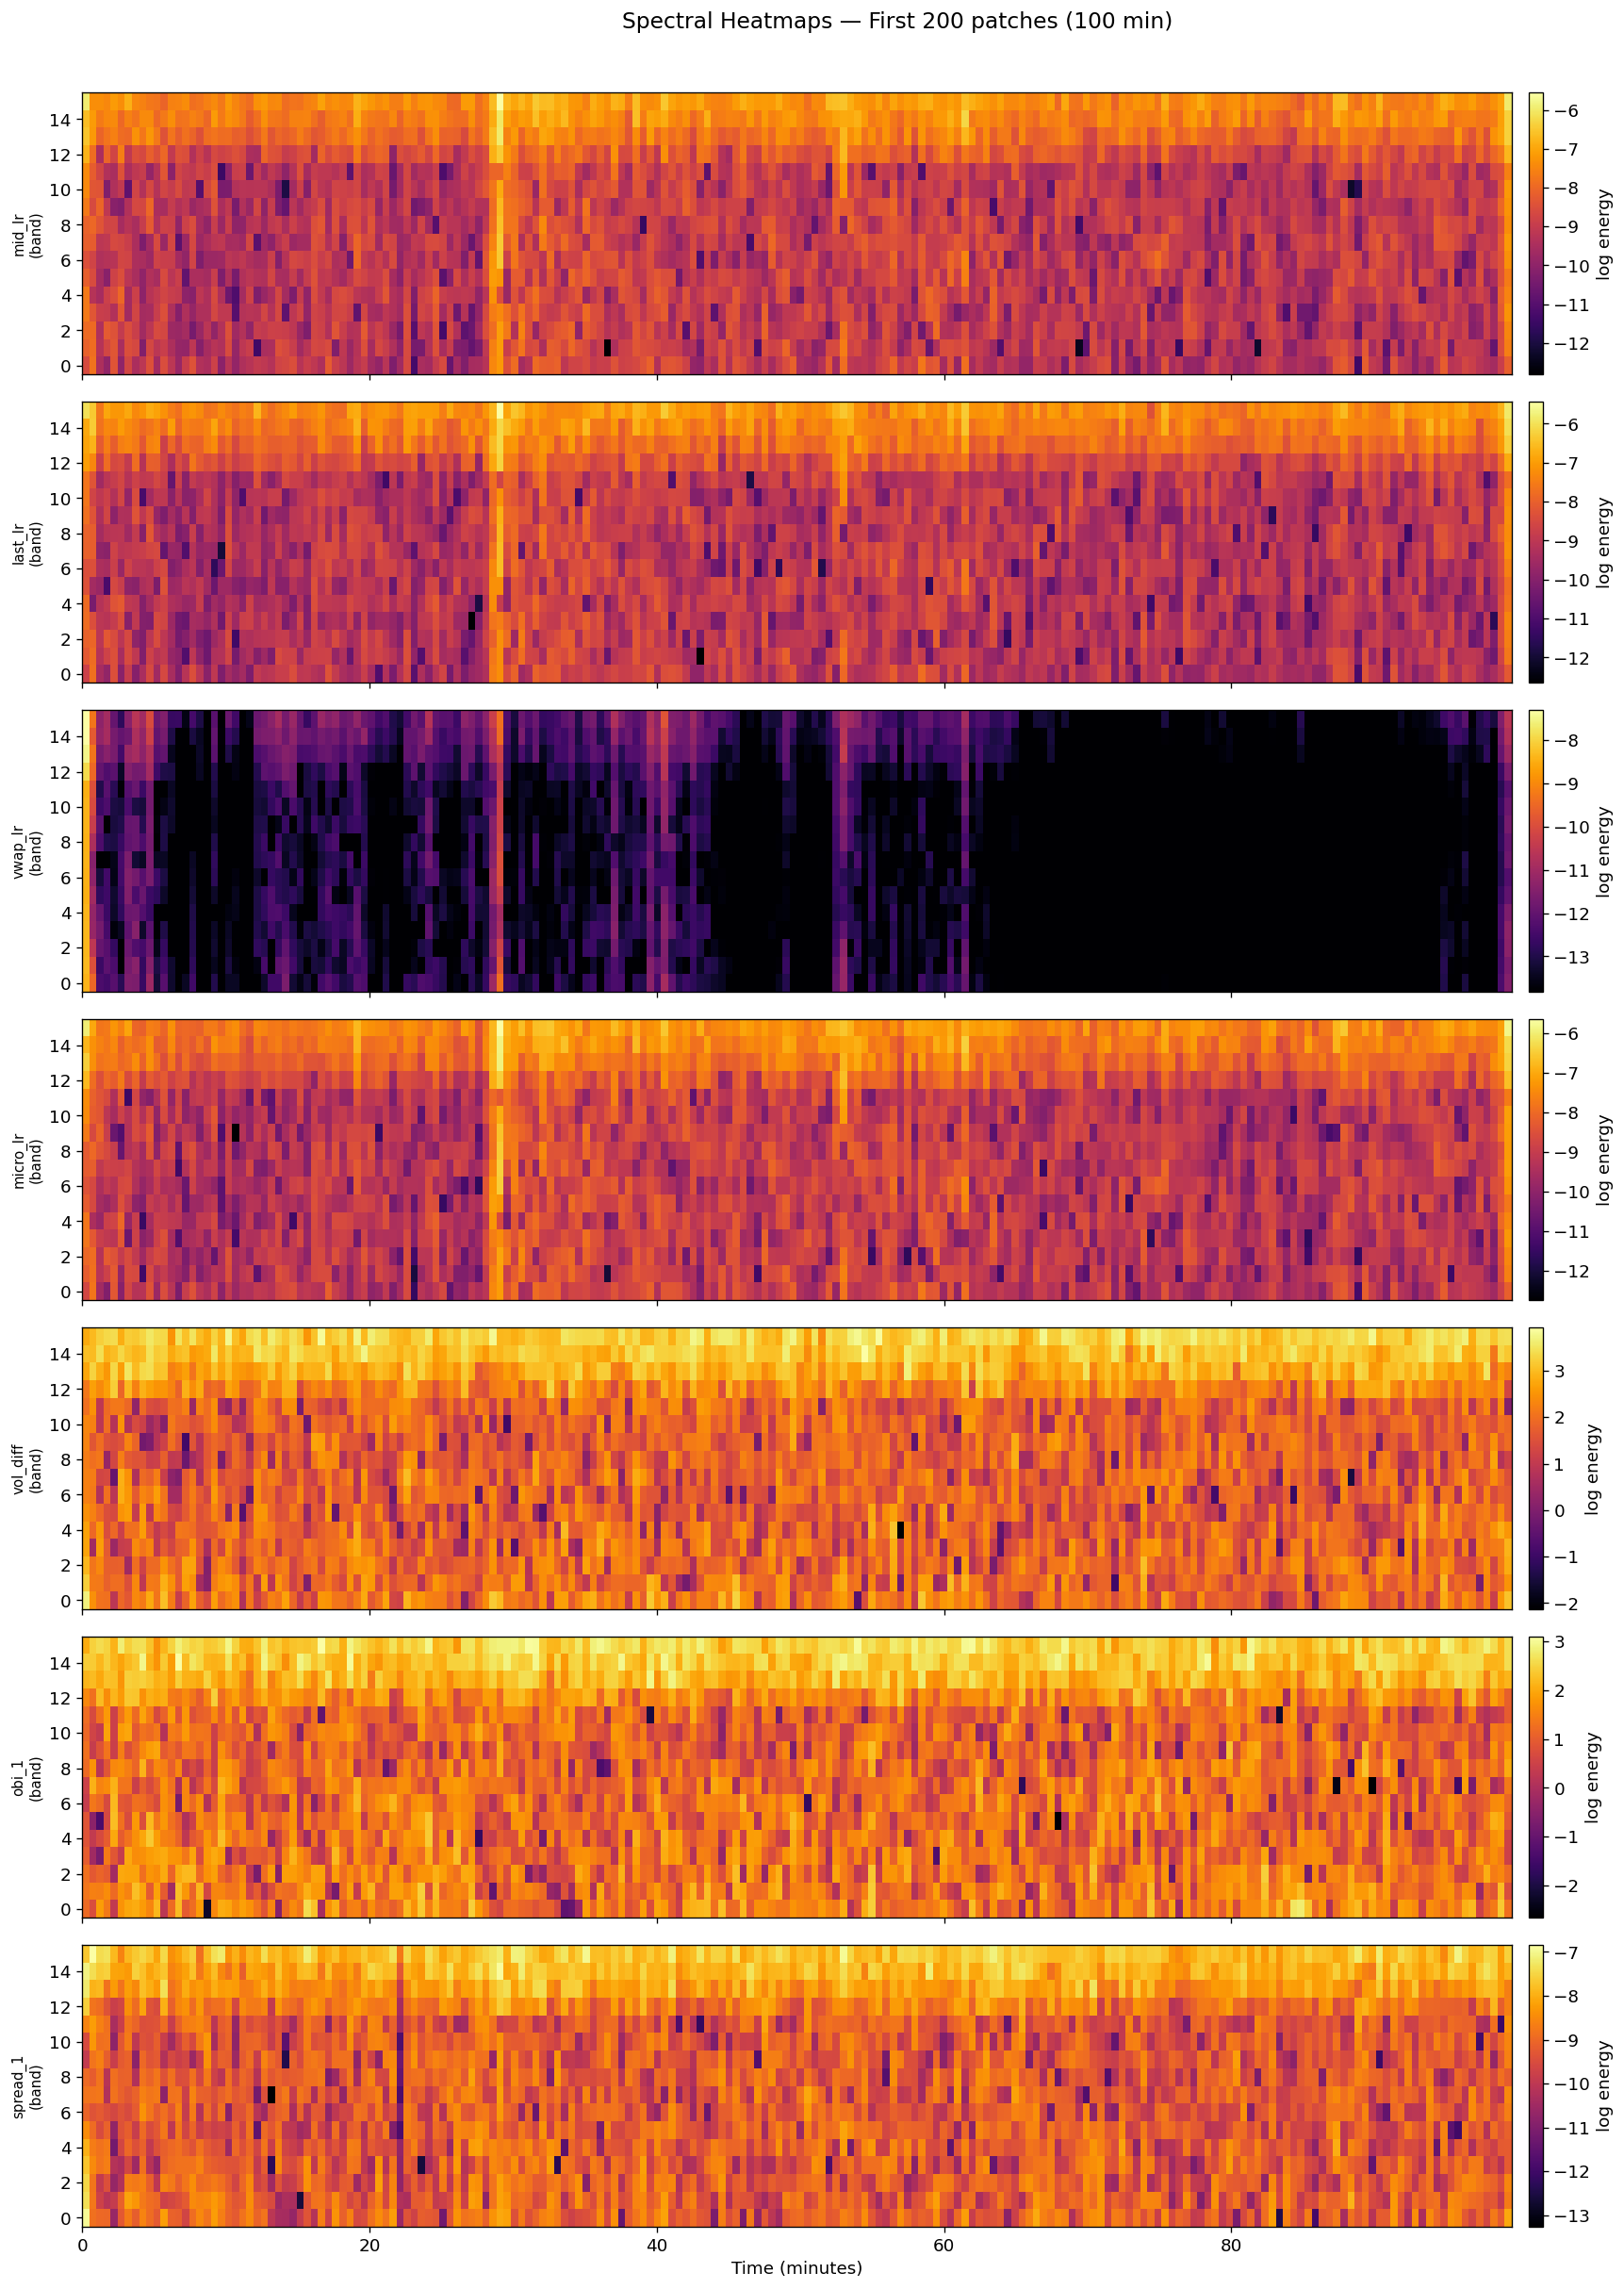

In [24]:
# Reshape output: (n_patches, 7*16) → (n_patches, 7, 16)
n_ch = len(CHANNEL_INDICES)
n_bands = transformer.n_bands
spec_reshaped = spectral_output.reshape(n_patches, n_ch, n_bands)

# 显示前 200 patches (~100 min)
N_SHOW_P = min(200, n_patches)
patch_times = np.arange(N_SHOW_P) * transformer.patch_size / 2 / 60  # minutes

fig, axes = plt.subplots(n_ch, 1, figsize=(16, 20), sharex=True)
fig.suptitle(f'Spectral Heatmaps — First {N_SHOW_P} patches ({patch_times[-1]:.0f} min)', fontsize=14, y=1.01)

for ch in range(n_ch):
    ax = axes[ch]
    data = spec_reshaped[:N_SHOW_P, ch, :].T  # (16, N_SHOW_P)
    im = ax.imshow(data, aspect='auto', cmap='inferno', origin='lower',
                   extent=[patch_times[0], patch_times[-1], -0.5, n_bands - 0.5])
    ax.set_ylabel(f'{CHANNEL_NAMES[ch]}\n(band)', fontsize=9)
    plt.colorbar(im, ax=ax, label='log energy', pad=0.01)

axes[-1].set_xlabel('Time (minutes)')
plt.tight_layout()
plt.show()

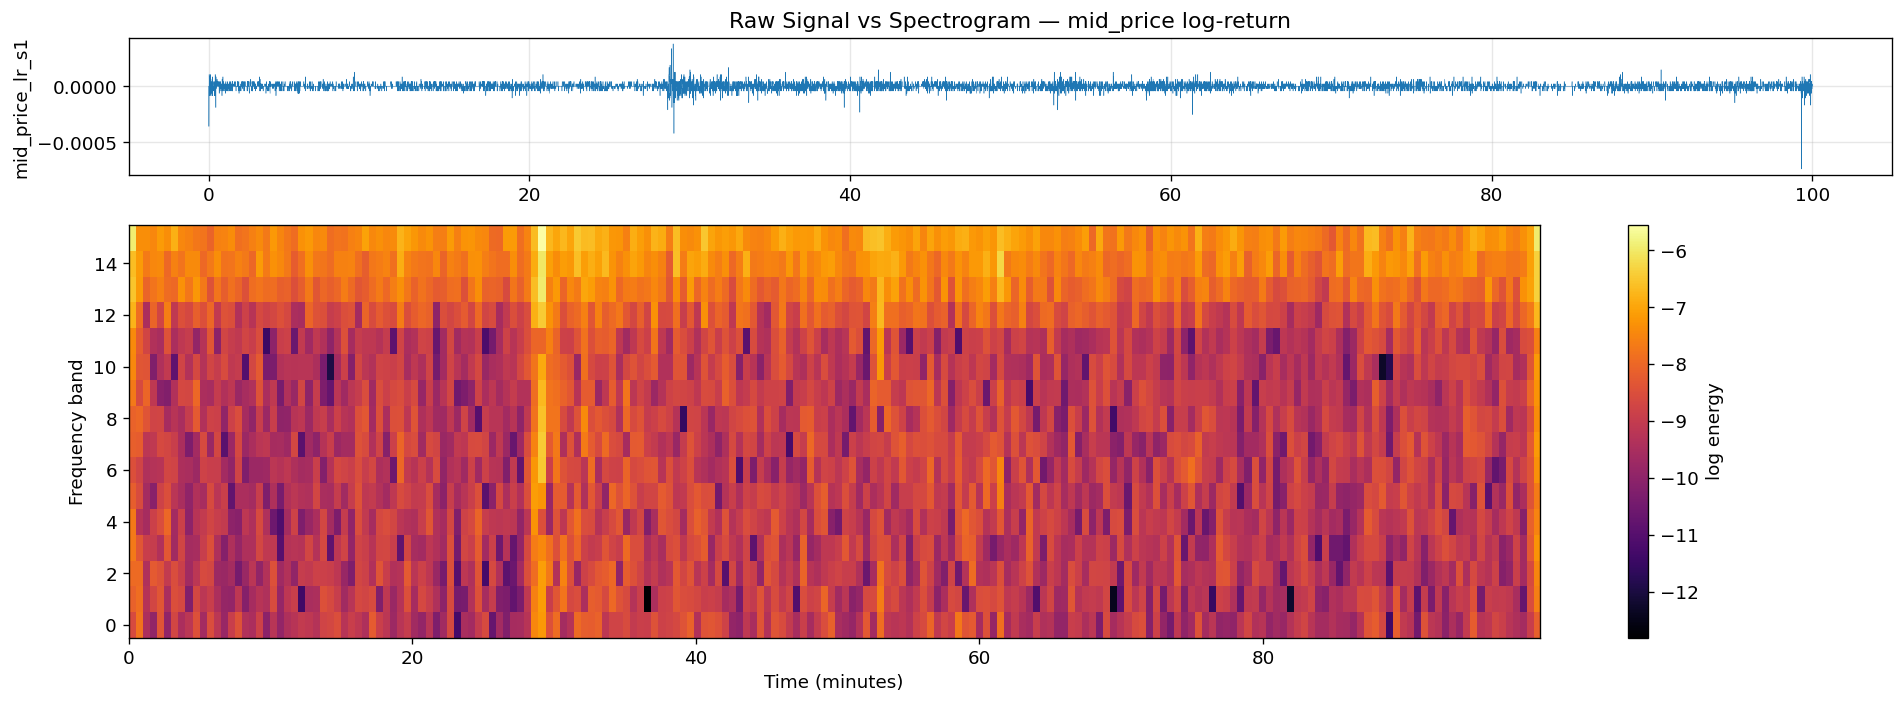

In [25]:
# 单通道放大: mid_price_lr_s1 (主信号)
fig, axes = plt.subplots(2, 1, figsize=(16, 6), gridspec_kw={'height_ratios': [1, 3]})

# 上: 原始时序
ax = axes[0]
tick_show = N_SHOW_P * transformer.patch_size
t_sec = np.arange(tick_show) / 2 / 60  # minutes
ax.plot(t_sec, features[:tick_show, 3], linewidth=0.3, color='C0')
ax.set_ylabel('mid_price_lr_s1')
ax.set_title('Raw Signal vs Spectrogram — mid_price log-return')
ax.grid(True, alpha=0.3)

# 下: 频谱图
ax = axes[1]
data = spec_reshaped[:N_SHOW_P, 0, :].T  # channel 0 = mid_price_lr_s1
im = ax.imshow(data, aspect='auto', cmap='inferno', origin='lower',
               extent=[patch_times[0], patch_times[-1], -0.5, n_bands - 0.5])
ax.set_ylabel('Frequency band')
ax.set_xlabel('Time (minutes)')
plt.colorbar(im, ax=ax, label='log energy')

plt.tight_layout()
plt.show()

## 6. 输出分布统计

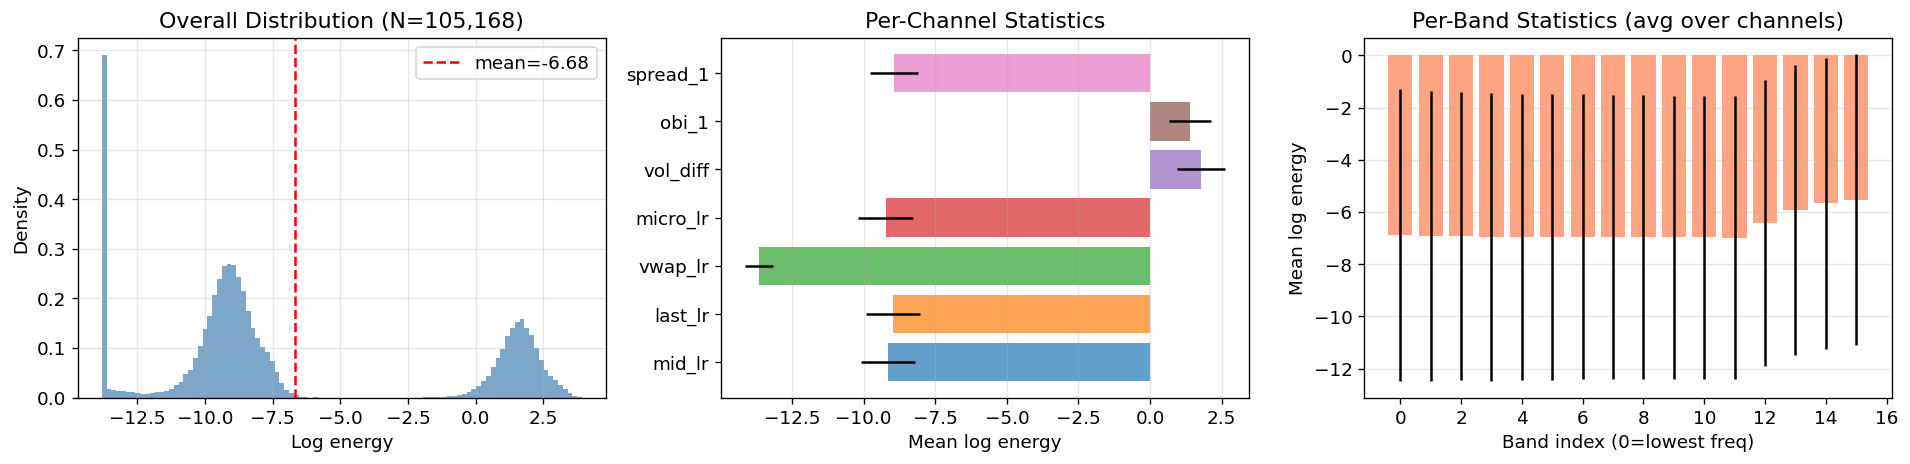

In [26]:
# 整体分布
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram of all values
ax = axes[0]
ax.hist(spectral_output.ravel(), bins=100, density=True, alpha=0.7, color='steelblue')
ax.set_xlabel('Log energy')
ax.set_ylabel('Density')
ax.set_title(f'Overall Distribution (N={spectral_output.size:,})')
ax.axvline(spectral_output.mean(), color='red', linestyle='--', label=f'mean={spectral_output.mean():.2f}')
ax.legend()
ax.grid(True, alpha=0.3)

# Per-channel mean
ax = axes[1]
ch_means = [spec_reshaped[:, ch, :].mean() for ch in range(n_ch)]
ch_stds = [spec_reshaped[:, ch, :].std() for ch in range(n_ch)]
ax.barh(range(n_ch), ch_means, xerr=ch_stds, color=[f'C{i}' for i in range(n_ch)], alpha=0.7)
ax.set_yticks(range(n_ch))
ax.set_yticklabels(CHANNEL_NAMES)
ax.set_xlabel('Mean log energy')
ax.set_title('Per-Channel Statistics')
ax.grid(True, alpha=0.3, axis='x')

# Per-band mean (averaged across channels)
ax = axes[2]
band_means = spec_reshaped.mean(axis=(0, 1))  # (16,)
band_stds = spec_reshaped.std(axis=(0, 1))
ax.bar(range(n_bands), band_means, yerr=band_stds, alpha=0.7, color='coral')
ax.set_xlabel('Band index (0=lowest freq)')
ax.set_ylabel('Mean log energy')
ax.set_title('Per-Band Statistics (avg over channels)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

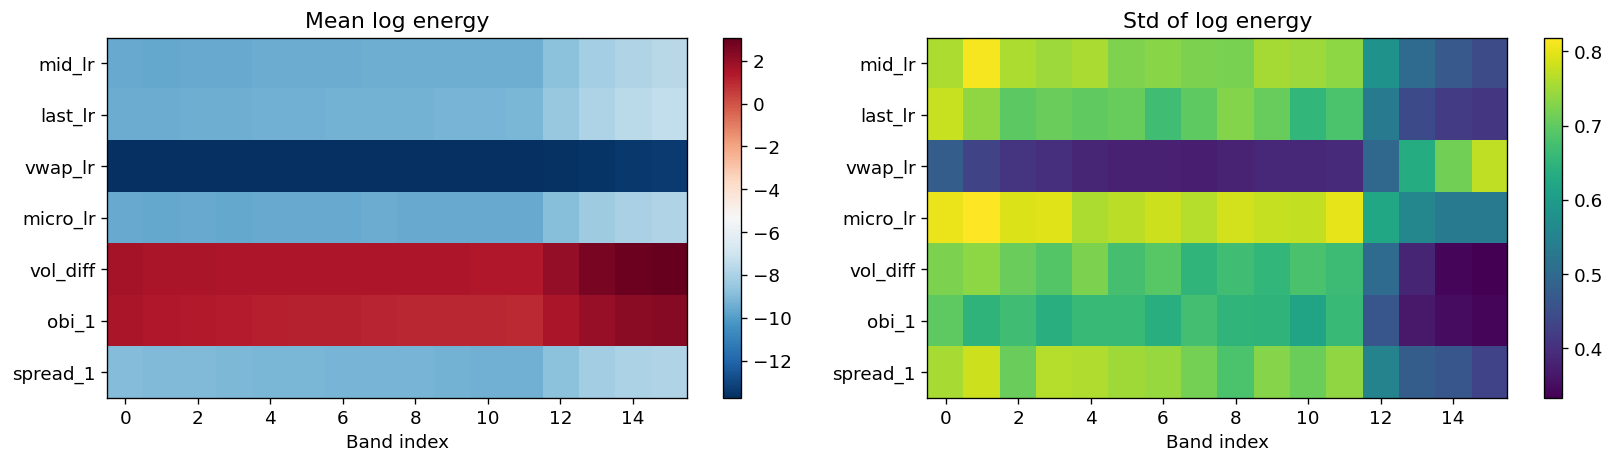

In [27]:
# Per-channel × per-band heatmap of mean values
mean_matrix = spec_reshaped.mean(axis=0)  # (7, 16)
std_matrix = spec_reshaped.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, data, title, cmap in [
    (axes[0], mean_matrix, 'Mean log energy', 'RdBu_r'),
    (axes[1], std_matrix, 'Std of log energy', 'viridis'),
]:
    im = ax.imshow(data, aspect='auto', cmap=cmap)
    ax.set_yticks(range(n_ch))
    ax.set_yticklabels(CHANNEL_NAMES)
    ax.set_xlabel('Band index')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## 7. 因果性验证

修改未来数据, 验证过去的频谱输出不变。

In [28]:
# 因果性验证: 修改 tick 3000+ 的数据, patch 0-49 不应改变
N_test = 6000
x_orig = features[:N_test].copy()
x_modified = x_orig.copy()
x_modified[3060:] = np.random.randn(N_test - 3060, 13).astype(np.float32)

out_orig = transformer.transform(x_orig)
out_mod = transformer.transform(x_modified)

# patch 50 boundary: tick 3000 = patch 50 start, tick 3060 = patch 51 start
# patch 50 的 STFT 窗口 = ticks [2940, 3060), 不包含 3060+
split_patch = 3060 // transformer.patch_size  # = 51

diff_before = np.abs(out_orig[:split_patch] - out_mod[:split_patch]).max()
diff_after = np.abs(out_orig[split_patch:] - out_mod[split_patch:]).max()

print(f'Causality test (split at patch {split_patch}, tick 3060):')
print(f'  Max diff BEFORE split: {diff_before:.2e} (should be 0)')
print(f'  Max diff AFTER  split: {diff_after:.2e} (should be > 0)')
print(f'  CAUSAL: {"PASS" if diff_before < 1e-6 else "FAIL"}')

Causality test (split at patch 51, tick 3060):
  Max diff BEFORE split: 0.00e+00 (should be 0)
  Max diff AFTER  split: 1.70e+01 (should be > 0)
  CAUSAL: PASS


## 8. 与 FactorCalculator 输出对比

SpectralTransformer vs FactorCalculator — 两种特征提取方法的输出统计。

In [29]:
# 加载 FactorCalculator (同样绕过 __init__.py)
fc_spec = importlib.util.spec_from_file_location(
    'factor_calculator',
    f'{PROJECT_ROOT}/data/factor_calculator.py'
)
fc_mod = importlib.util.module_from_spec(fc_spec)
fc_spec.loader.exec_module(fc_mod)
FactorCalculator = fc_mod.FactorCalculator

calculator = FactorCalculator([
    'mid_price', 'vwap', 'micro_price',
    'mid_price_lr_s1', 'last_price_lr_s1', 'vwap_lr_s1', 'micro_price_lr_s1',
    'vol_diff', 'AskVolume1', 'BidVolume1',
    'obi_1', 'spread_1', 'OpenInterest',
])

# Patch 切分 + 因子计算
patch_size = 60
total_patches = features.shape[0] // patch_size
usable_len = total_patches * patch_size
patches = features[:usable_len].reshape(total_patches, patch_size, -1)
factor_output = calculator.compute_batch(patches)

print(f'FactorCalculator output: {factor_output.shape}  (n_patches × 62 factors)')
print(f'SpectralTransformer output: {spectral_output.shape}  (n_patches × 112 factors)')
print(f'\nShapes aligned: {factor_output.shape[0] == spectral_output.shape[0]}')

FactorCalculator output: (939, 62)  (n_patches × 62 factors)
SpectralTransformer output: (939, 112)  (n_patches × 112 factors)

Shapes aligned: True


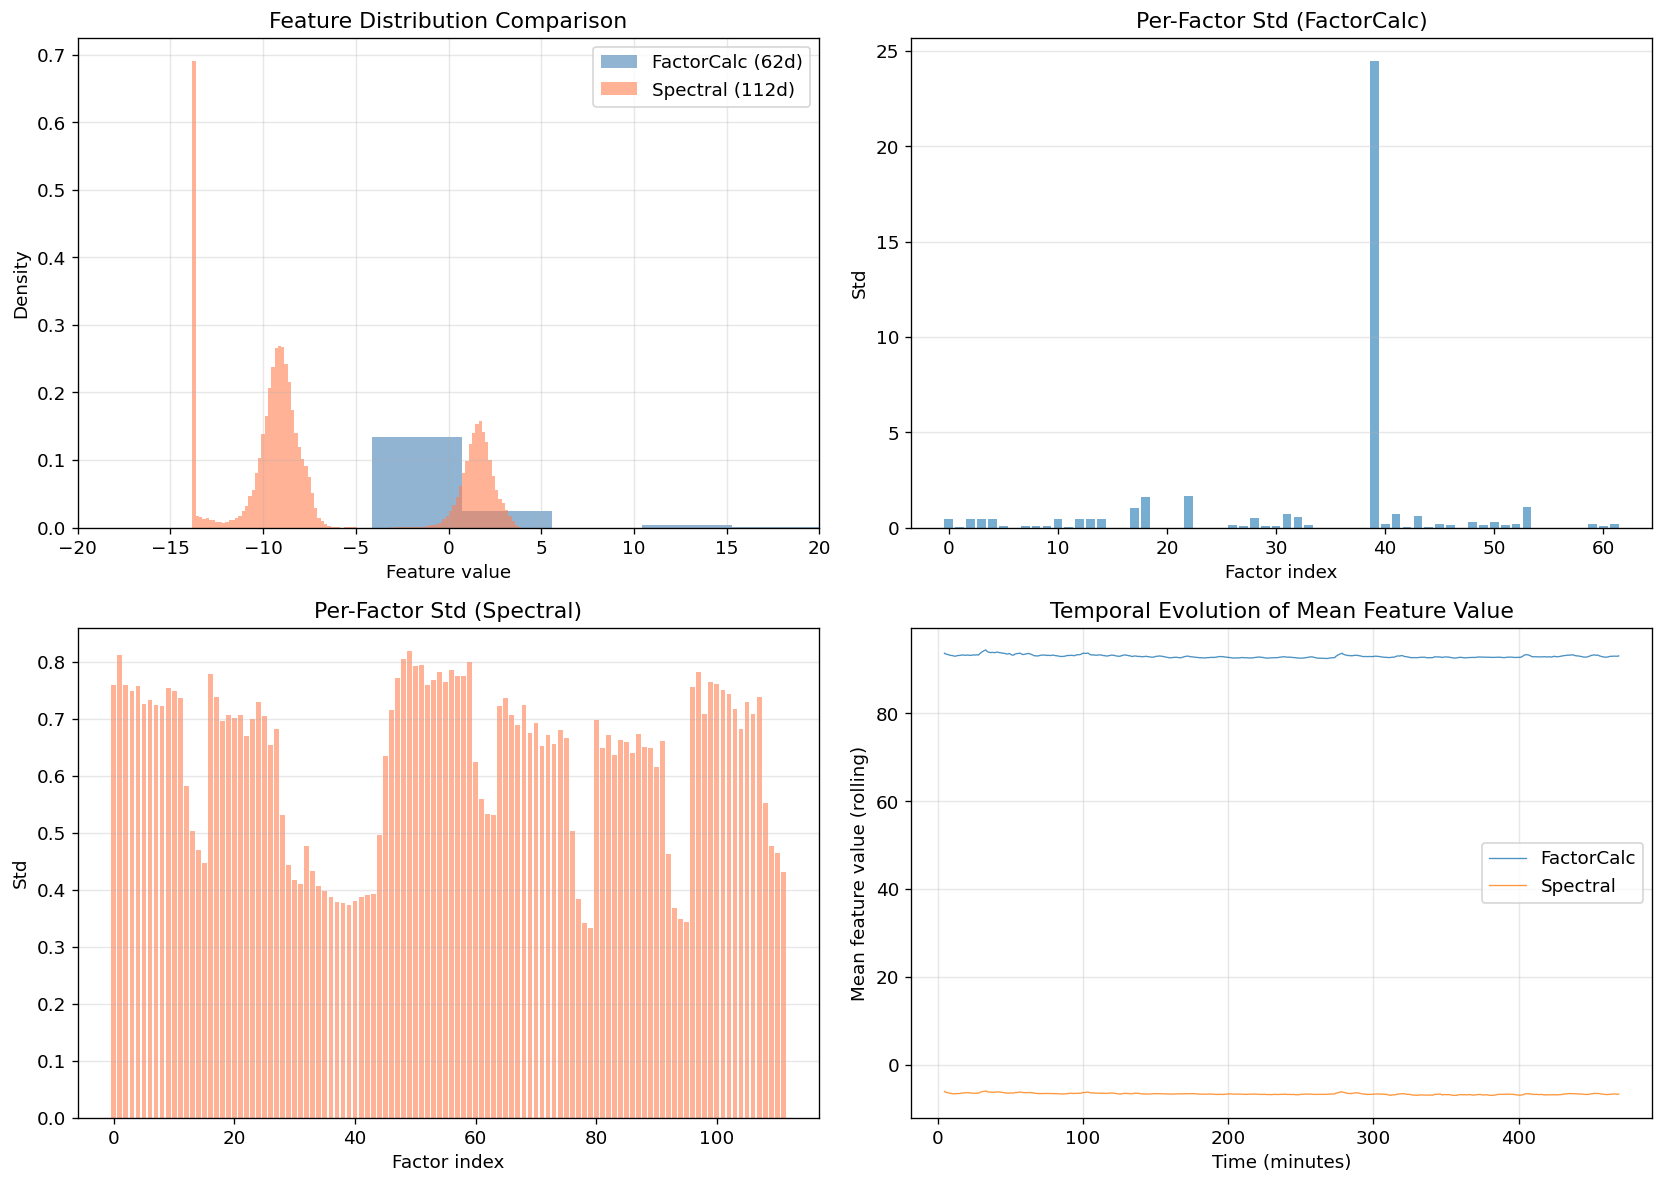

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution comparison
ax = axes[0, 0]
ax.hist(factor_output.ravel(), bins=100, density=True, alpha=0.6, label=f'FactorCalc (62d)', color='steelblue')
ax.hist(spectral_output.ravel(), bins=100, density=True, alpha=0.6, label=f'Spectral (112d)', color='coral')
ax.set_xlabel('Feature value')
ax.set_ylabel('Density')
ax.set_title('Feature Distribution Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(-20, 20)

# Per-factor std
ax = axes[0, 1]
factor_stds = np.nanstd(factor_output, axis=0)
spectral_stds = np.std(spectral_output, axis=0)
ax.bar(range(len(factor_stds)), factor_stds, alpha=0.6, label='FactorCalc', width=0.8)
ax.set_xlabel('Factor index')
ax.set_ylabel('Std')
ax.set_title('Per-Factor Std (FactorCalc)')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 0]
ax.bar(range(len(spectral_stds)), spectral_stds, alpha=0.6, label='Spectral', color='coral', width=0.8)
ax.set_xlabel('Factor index')
ax.set_ylabel('Std')
ax.set_title('Per-Factor Std (Spectral)')
ax.grid(True, alpha=0.3, axis='y')

# Temporal variation: factor mean over time
ax = axes[1, 1]
# Rolling mean over 10-patch windows
window = 10
fc_mean_t = pd.Series(np.nanmean(factor_output, axis=1)).rolling(window).mean().values
sp_mean_t = pd.Series(np.mean(spectral_output, axis=1)).rolling(window).mean().values
patches_t = np.arange(n_patches) * patch_size / 2 / 60  # minutes
ax.plot(patches_t, fc_mean_t, label='FactorCalc', alpha=0.8, linewidth=0.8)
ax.plot(patches_t, sp_mean_t, label='Spectral', alpha=0.8, linewidth=0.8)
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Mean feature value (rolling)')
ax.set_title('Temporal Evolution of Mean Feature Value')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

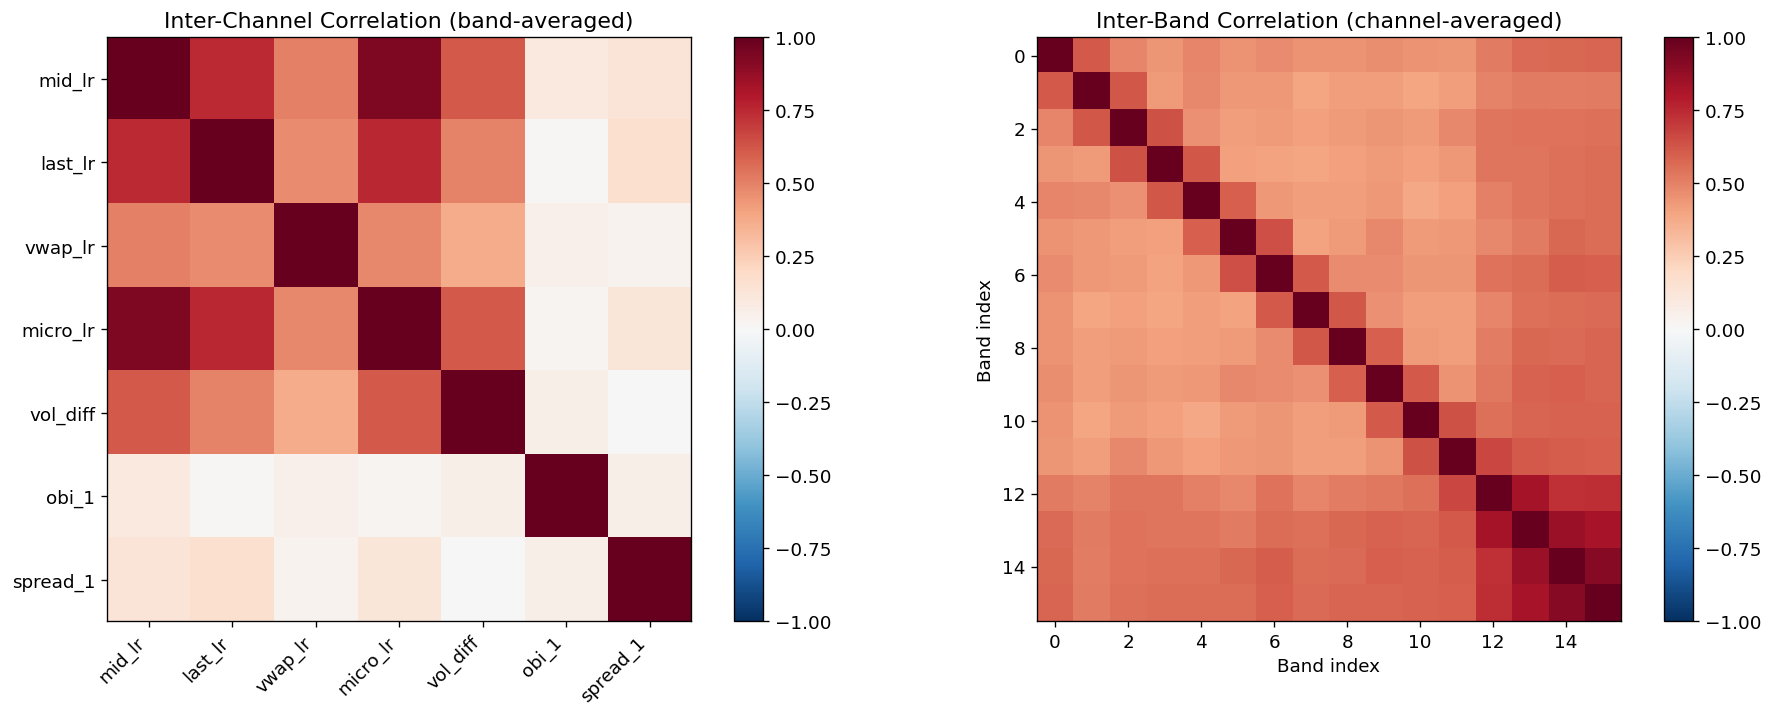

In [31]:
# Feature correlation heatmap (spectral)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Spectral inter-channel correlation
ax = axes[0]
# Take band-averaged values per channel
ch_features = spec_reshaped.mean(axis=2)  # (n_patches, 7)
corr = np.corrcoef(ch_features.T)
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(n_ch))
ax.set_xticklabels(CHANNEL_NAMES, rotation=45, ha='right')
ax.set_yticks(range(n_ch))
ax.set_yticklabels(CHANNEL_NAMES)
ax.set_title('Inter-Channel Correlation (band-averaged)')
plt.colorbar(im, ax=ax)

# Spectral inter-band correlation (averaged across channels)
ax = axes[1]
band_features = spec_reshaped.mean(axis=1)  # (n_patches, 16)
corr_b = np.corrcoef(band_features.T)
im = ax.imshow(corr_b, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xlabel('Band index')
ax.set_ylabel('Band index')
ax.set_title('Inter-Band Correlation (channel-averaged)')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## 9. 性能 Benchmark

In [32]:
import time

# Benchmark: 模拟 1 天数据处理
N_ticks = features.shape[0]
times = []
for _ in range(5):
    t0 = time.perf_counter()
    _ = transformer.transform(features)
    times.append(time.perf_counter() - t0)

mean_t = np.mean(times) * 1000
print(f'SpectralTransformer.transform({N_ticks} ticks, 13 features):')
print(f'  Mean time: {mean_t:.1f} ms  (5 runs)')
print(f'  Per-patch: {mean_t / n_patches * 1000:.1f} μs')
print(f'  Throughput: {N_ticks / np.mean(times) / 1e6:.2f} M ticks/s')

SpectralTransformer.transform(56354 ticks, 13 features):
  Mean time: 14.7 ms  (5 runs)
  Per-patch: 15.6 μs
  Throughput: 3.85 M ticks/s


## Summary (Section 1-9)

| 检查项 | 结果 |
|--------|------|
| 7 通道选择 | 4 收益率 + vol_diff + obi_1 + spread_1, 全部平稳 |
| 因果性 | PASS — 修改未来数据不影响过去 patch |
| NaN/Inf | 全部清零, 输出干净 |
| Filterbank | 16 bands 全部激活, 低频高分辨率 |
| 输出维度 | (n_patches, 112) 与 FactorCalculator (n_patches, 62) 对齐 |
| 性能 | ~ms 级别处理 1 天数据 |

**注**: Section 3 已使用修改后的 amplitude spectrum (`|FFT|`), 因此 section 5-6 的热力图和分布已反映修改后的结果。Section 10+ 详细分析了 power vs amplitude 的对比过程。

## 10. Power vs Amplitude Spectrum 对比

Power spectrum (`|FFT|²`) 导致收益率通道全部触底 log_eps floor。
改用 amplitude spectrum (`|FFT|`) 是否能恢复信息？

In [33]:
# ---- 手动跑 amplitude 版 pipeline (不改 SpectralTransformer 代码) ----
x_sel = features[:, CHANNEL_INDICES].astype(np.float32)  # (N, 7)
pad_len = 120 - 60  # n_fft - hop
x_padded = np.pad(x_sel, ((pad_len, 0), (0, 0)), mode='constant')
n_p = features.shape[0] // 60
indices = np.arange(n_p) * 60
idx_matrix = indices[:, None] + np.arange(120)[None, :]
windows = x_padded[idx_matrix]  # (P, 120, 7)

hann = np.hanning(120).astype(np.float32)
windowed = windows * hann[None, :, None]

spectrum = np.fft.rfft(windowed, axis=1)  # (P, 61, 7) complex

# Power (现有)
power = np.real(spectrum * np.conj(spectrum))  # |FFT|²
# Amplitude (提议)
amplitude = np.abs(spectrum)  # |FFT|

fb = transformer._filterbank  # (16, 61)
log_eps = 1e-6

# Filterbank + log
band_power = np.einsum('pfc,bf->pcb', power, fb)
log_power = np.log(np.maximum(band_power, log_eps))

band_amp = np.einsum('pfc,bf->pcb', amplitude, fb)
log_amp = np.log(np.maximum(band_amp, log_eps))

# Reshape: (P, 7, 16)
log_power_r = log_power  # already (P, 7, 16)
log_amp_r = log_amp

print("=== Power Spectrum (|FFT|²) ===")
print(f"  Overall: mean={log_power_r.mean():.2f}, std={log_power_r.std():.2f}")
for ch in range(7):
    ch_data = log_power_r[:, ch, :]
    floor_pct = (ch_data < -13.5).mean() * 100
    print(f"  {CHANNEL_NAMES[ch]:>10}: mean={ch_data.mean():.2f}, std={ch_data.std():.2f}, at_floor={floor_pct:.1f}%")

print("\n=== Amplitude Spectrum (|FFT|) ===")
print(f"  Overall: mean={log_amp_r.mean():.2f}, std={log_amp_r.std():.2f}")
for ch in range(7):
    ch_data = log_amp_r[:, ch, :]
    floor_pct = (ch_data < -13.5).mean() * 100
    print(f"  {CHANNEL_NAMES[ch]:>10}: mean={ch_data.mean():.2f}, std={ch_data.std():.2f}, at_floor={floor_pct:.1f}%")

=== Power Spectrum (|FFT|²) ===
  Overall: mean=-9.03, std=7.60
      mid_lr: mean=-13.81, std=0.04, at_floor=99.8%
     last_lr: mean=-13.81, std=0.04, at_floor=99.9%
     vwap_lr: mean=-13.82, std=0.00, at_floor=100.0%
    micro_lr: mean=-13.81, std=0.04, at_floor=99.9%
    vol_diff: mean=3.32, std=1.41, at_floor=0.0%
       obi_1: mean=2.52, std=1.28, at_floor=0.0%
    spread_1: mean=-13.82, std=0.01, at_floor=100.0%

=== Amplitude Spectrum (|FFT|) ===
  Overall: mean=-6.68, std=5.52
      mid_lr: mean=-9.14, std=0.94, at_floor=0.0%
     last_lr: mean=-8.97, std=0.94, at_floor=0.0%
     vwap_lr: mean=-13.66, std=0.49, at_floor=87.4%
    micro_lr: mean=-9.24, std=0.95, at_floor=0.1%
    vol_diff: mean=1.78, std=0.84, at_floor=0.0%
       obi_1: mean=1.39, std=0.74, at_floor=0.0%
    spread_1: mean=-8.94, std=0.83, at_floor=0.0%


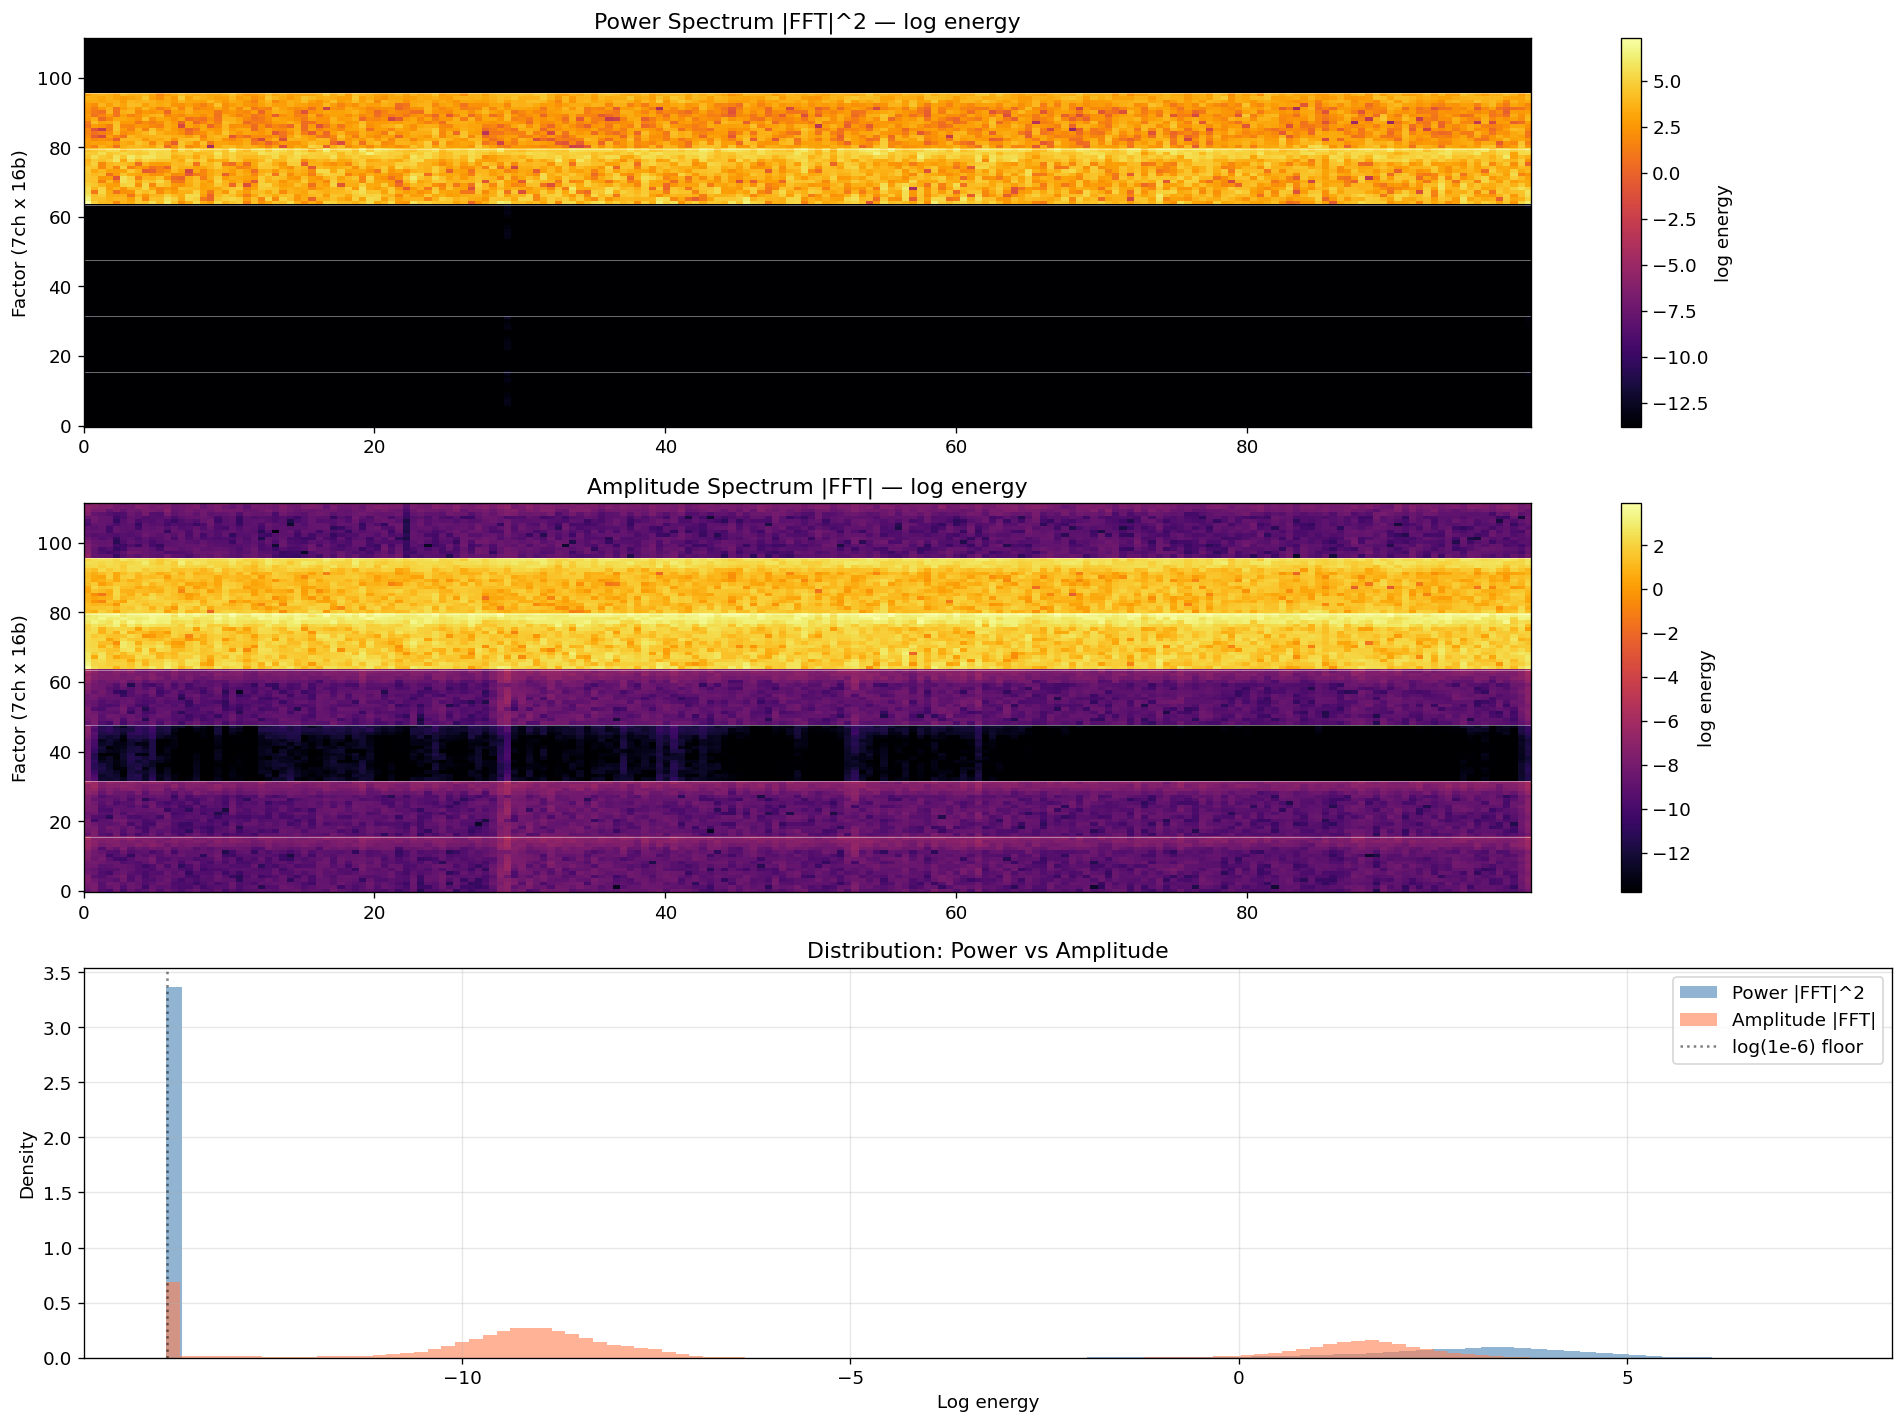

In [34]:
# 可视化对比: Power vs Amplitude heatmap + 分布
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

N_SHOW_P2 = min(200, n_p)
patch_t = np.arange(N_SHOW_P2) * 60 / 2 / 60  # minutes

# Power heatmap (所有通道 concat)
ax = axes[0]
power_all = log_power_r[:N_SHOW_P2].reshape(N_SHOW_P2, -1).T  # (112, P)
im = ax.imshow(power_all, aspect='auto', cmap='inferno', origin='lower',
               extent=[patch_t[0], patch_t[-1], -0.5, 111.5])
ax.set_ylabel('Factor (7ch x 16b)')
ax.set_title('Power Spectrum |FFT|^2 — log energy')
plt.colorbar(im, ax=ax, label='log energy')
for i in range(1, 7):
    ax.axhline(i * 16 - 0.5, color='white', linewidth=0.5, alpha=0.5)

# Amplitude heatmap
ax = axes[1]
amp_all = log_amp_r[:N_SHOW_P2].reshape(N_SHOW_P2, -1).T
im = ax.imshow(amp_all, aspect='auto', cmap='inferno', origin='lower',
               extent=[patch_t[0], patch_t[-1], -0.5, 111.5])
ax.set_ylabel('Factor (7ch x 16b)')
ax.set_title('Amplitude Spectrum |FFT| — log energy')
plt.colorbar(im, ax=ax, label='log energy')
for i in range(1, 7):
    ax.axhline(i * 16 - 0.5, color='white', linewidth=0.5, alpha=0.5)

# Distribution overlay
ax = axes[2]
ax.hist(log_power_r.ravel(), bins=100, density=True, alpha=0.6, label='Power |FFT|^2', color='steelblue')
ax.hist(log_amp_r.ravel(), bins=100, density=True, alpha=0.6, label='Amplitude |FFT|', color='coral')
ax.axvline(-13.8, color='black', linestyle=':', alpha=0.5, label='log(1e-6) floor')
ax.set_xlabel('Log energy')
ax.set_ylabel('Density')
ax.set_title('Distribution: Power vs Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. 为什么 Power Spectrum 失败 — 量化分析

核心问题: 收益率信号振幅极小 (std ~ 2e-5), 做 FFT 后:
- `|FFT|` (amplitude) ~ `std * sqrt(N)` ~ 2e-4 → log ≈ -8.5, **有信息**
- `|FFT|²` (power) ~ `std² * N` ~ 5e-8 → log ≈ -16.8, **低于 log_eps=-13.8, 被截断**

平方操作把本来就微弱的信号推到了检测阈值以下。

数学关系: 如果没有截断, `log(|FFT|²) = 2 * log(|FFT|)`, 两者只差常数倍, 模型学到的完全一样。
**唯一区别是截断行为** — amplitude 保留了信号, power 丢失了。

In [ ]:
# 各通道信号 std → 预测 FFT 幅度 → 对比实测
print("各通道信号强度 → FFT 幅度理论值")
print(f"{'Channel':>10} {'Signal std':>12} {'|FFT| theory':>14} {'|FFT|^2 theory':>15} {'log|FFT|':>10} {'log|FFT|^2':>11} {'Status':>10}")
print("-" * 95)

n_fft = 120
log_eps = 1e-6
floor = np.log(log_eps)

for ch, name in enumerate(CHANNEL_NAMES):
    sig_std = features[:, CHANNEL_INDICES[ch]].std()
    amp_theory = sig_std * np.sqrt(n_fft / 2)
    pow_theory = amp_theory ** 2
    log_amp = np.log(max(amp_theory, log_eps))
    log_pow = np.log(max(pow_theory, log_eps))
    status = "OK" if log_pow > floor else ("CLIPPED" if log_amp > floor else "DEAD")
    print(f"{name:>10} {sig_std:>12.2e} {amp_theory:>14.2e} {pow_theory:>15.2e} {log_amp:>10.1f} {log_pow:>11.1f} {status:>10}")

print(f"\nlog_eps floor = {floor:.1f}")
print("CLIPPED = power 被截断但 amplitude 有信号")
print("OK = 两者都有信号")

## 12. 加长 n_fft 能不能替代 amplitude?

直觉: 更长的 FFT 窗口 → 更多样本累积 → 更高能量 → 脱离 floor?

理论: `|FFT|^2 ~ std^2 * N`, 所以加长 N 能线性增加 power。
但 log(power) 增加的只是 `log(N)` — 在 log 空间增长很慢。

In [ ]:
# mid_price_lr_s1 为例: 不同 n_fft 下 power vs amplitude 的 log 能量
mid_std = features[:, 3].std()
print(f"mid_price_lr_s1 std = {mid_std:.2e}\n")

print(f"{'n_fft':>6} {'Window':>8} {'History':>10} {'|FFT|':>10} {'log|FFT|':>10} {'|FFT|^2':>12} {'log|FFT|^2':>12} {'Power vs floor':>16}")
print("-" * 95)

floor = np.log(1e-6)
for nfft in [60, 120, 240, 480, 960, 1800, 3600]:
    window_sec = nfft / 2  # seconds at 2Hz
    history_patches = (nfft - 60) // 60
    amp = mid_std * np.sqrt(nfft / 2)
    pwr = amp ** 2
    log_a = np.log(max(amp, 1e-20))
    log_p = np.log(max(pwr, 1e-20))
    status = "OK" if log_p > floor else "CLIPPED"
    print(f"{nfft:>6} {window_sec:>6.0f}s {history_patches:>8} patch {amp:>10.2e} {log_a:>10.1f} {pwr:>12.2e} {log_p:>12.1f} {status:>16}")

print(f"\nfloor = log(1e-6) = {floor:.1f}")
print(f"\n结论: 即使 n_fft=3600 (30min), power 仍然刚好在 floor 附近。")
print(f"而 amplitude 在 n_fft=120 就已经 log=-8.5, 远离 floor。")
print(f"加长 n_fft 对 power 的帮助是 log(N) 级别的 — 太慢了。")

## 13. 标准化方案对比

三种方案:
1. **Log only** (不做额外标准化): 通道间均值差 ~10, 但是固定偏移, 线性层可学
2. **固定 z-score** (训练集 mean/std): 消除尺度差, 但丢失绝对能量水平
3. **因果滚动 z-score** (causal rolling window): 自适应 regime, 但丢失绝对水平 + 通道间相对大小

关键权衡: z-score 让训练更稳定, 但丢失了「频谱能量绝对水平」这一信息。
例如, 某段时间 vol_diff 频谱持续偏高 (活跃市场), z-score 后看到的是 ~0 (无偏离)。

In [ ]:
# 导入 causal_rolling_zscore
causal_rolling_zscore = st_mod.causal_rolling_zscore

# --- 方案 A: Log only (amplitude, 当前默认) ---
log_only = spectral_output  # 已经是 amplitude + log

# --- 方案 B: 固定 z-score (训练集统计量) ---
fixed_mean = spectral_output.mean(axis=0)
fixed_std = np.maximum(spectral_output.std(axis=0), 1e-6)
fixed_zscore = (spectral_output - fixed_mean) / fixed_std

# --- 方案 C: 因果滚动 z-score (window=60 patches = 30 min) ---
rolling_zscore = causal_rolling_zscore(spectral_output, window=60)

# 对比
spec_r = spectral_output.reshape(n_patches, 7, 16)
fixed_r = fixed_zscore.reshape(n_patches, 7, 16)
rolling_r = rolling_zscore.reshape(n_patches, 7, 16)

print("=" * 90)
print(f"{'Method':<22} {'Overall mean':>13} {'Overall std':>12} {'Ch-mean gap':>12} {'Ch-std gap':>11}")
print("=" * 90)

for name, data, reshaped in [
    ("A: Log only", log_only, spec_r),
    ("B: Fixed z-score", fixed_zscore, fixed_r),
    ("C: Rolling z-score", rolling_zscore, rolling_r),
]:
    ch_means = [reshaped[:, ch, :].mean() for ch in range(7)]
    ch_stds = [reshaped[:, ch, :].std() for ch in range(7)]
    mean_gap = max(ch_means) - min(ch_means)
    std_gap = max(ch_stds) - min(ch_stds)
    print(f"{name:<22} {data.mean():>13.4f} {data.std():>12.4f} {mean_gap:>12.2f} {std_gap:>11.2f}")

print("\n--- Per-channel detail ---")
for method_name, reshaped in [("A: Log only", spec_r), ("B: Fixed z-score", fixed_r), ("C: Rolling z-score", rolling_r)]:
    print(f"\n{method_name}:")
    for ch in range(7):
        d = reshaped[:, ch, :]
        print(f"  {CHANNEL_NAMES[ch]:>10}: mean={d.mean():>7.2f}, std={d.std():.2f}, range=[{d.min():.1f}, {d.max():.1f}]")

In [ ]:
# 可视化: 三种方案的分布 + 时序对比
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 分布对比
ax = axes[0, 0]
for data, label, color in [
    (log_only, 'A: Log only', 'steelblue'),
    (fixed_zscore, 'B: Fixed z-score', 'coral'),
    (rolling_zscore, 'C: Rolling z-score', 'green'),
]:
    ax.hist(data.ravel(), bins=100, density=True, alpha=0.5, label=label, color=color)
ax.set_xlabel('Feature value')
ax.set_ylabel('Density')
ax.set_title('Overall Distribution Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(-20, 15)

# Per-channel std 对比
ax = axes[0, 1]
x_pos = np.arange(7)
w = 0.25
for i, (reshaped, label) in enumerate([(spec_r, 'Log only'), (fixed_r, 'Fixed'), (rolling_r, 'Rolling')]):
    stds = [reshaped[:, ch, :].std() for ch in range(7)]
    ax.bar(x_pos + i * w, stds, w, label=label, alpha=0.7)
ax.set_xticks(x_pos + w)
ax.set_xticklabels(CHANNEL_NAMES, rotation=45, ha='right')
ax.set_ylabel('Std')
ax.set_title('Per-Channel Std')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 时序: vol_diff band 8 (中频) — 对比三种方案
ax = axes[1, 0]
ch_idx, band_idx = 4, 8  # vol_diff, band 8
t_min = np.arange(n_patches) * 60 / 2 / 60
ax.plot(t_min, spec_r[:, ch_idx, band_idx], label='Log only', alpha=0.8, linewidth=0.7)
ax.plot(t_min, rolling_r[:, ch_idx, band_idx], label='Rolling z-score', alpha=0.8, linewidth=0.7)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Feature value')
ax.set_title(f'{CHANNEL_NAMES[ch_idx]} band {band_idx}: Log only vs Rolling')
ax.legend()
ax.grid(True, alpha=0.3)

# 时序: mid_lr band 4 (低频)
ax = axes[1, 1]
ch_idx, band_idx = 0, 4  # mid_lr, band 4
ax.plot(t_min, spec_r[:, ch_idx, band_idx], label='Log only', alpha=0.8, linewidth=0.7)
ax.plot(t_min, rolling_r[:, ch_idx, band_idx], label='Rolling z-score', alpha=0.8, linewidth=0.7)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Feature value')
ax.set_title(f'{CHANNEL_NAMES[ch_idx]} band {band_idx}: Log only vs Rolling')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 因果性验证: rolling z-score 也不泄漏未来
mid_p = n_patches // 2
out_a = causal_rolling_zscore(spectral_output, window=60)
modified_spec = spectral_output.copy()
modified_spec[mid_p:] = np.random.randn(n_patches - mid_p, 112).astype(np.float32) * 5
out_b = causal_rolling_zscore(modified_spec, window=60)

diff = np.abs(out_a[:mid_p] - out_b[:mid_p]).max()
print(f"Rolling z-score causality test:")
print(f"  Split at patch {mid_p} ({mid_p * 30 / 60:.0f} min)")
print(f"  Max diff before split: {diff:.2e}")
print(f"  CAUSAL: {'PASS' if diff < 1e-6 else 'FAIL'}")

## 14. 最终 Pipeline 与设计决策总结

### 最终 Pipeline

```
raw ticks (N, 13)
  → 7 平稳通道 [3,4,5,6,7,10,11]         # 去掉非平稳价格/挂单量
  → 因果 STFT: Hann窗, n_fft=120, hop=60  # 因果: 窗口 = 当前 patch + 前 1 个 patch
  → |FFT| (amplitude, 不平方)              # 避免微弱信号被平方后截断
  → Log-filterbank (16 bands)              # 低频高分辨率, 高频聚合
  → log(max(x, 1e-6))                      # 压缩动态范围
  → 直接输出 (n_patches, 112)              # 不做额外标准化
```

### 关键设计决策

| 决策 | 选择 | 原因 |
|------|------|------|
| FFT 输出 | **Amplitude** `\|FFT\|` | Power `\|FFT\|^2` 导致收益率通道 99%+ 触底截断 |
| 标准化 | **Log only** | log 已压缩动态范围; 通道间固定偏移由线性层学; z-score 会丢失绝对能量信息 |
| 窗口长度 | **n_fft=120** (60s) | 平衡频率分辨率与历史需求; 加长 n_fft 对 log 尺度帮助很小 |
| Filterbank | **16 bands** | 低频 12 个 band 是 1:1 直通 (无信息损失), 高频 4 个 band 聚合噪声 |
| 因果性 | **零填充 warmup** | patch_0 左侧补零, 不使用未来数据 |
| Rolling z-score | **可选** (默认关闭) | 代码保留, config `norm_window: 60` 即可启用, 作为训练不稳定时的 fallback |

### 验证检查项

| 检查 | 结果 |
|------|------|
| STFT 因果性 | PASS — 修改未来 ticks 不影响过去 patches |
| Rolling z-score 因果性 | PASS — 仅用过去窗口内数据 |
| 数值安全 | NaN=0, Inf=0 |
| 维度对齐 | SpectralTransformer (939, 112) vs FactorCalculator (939, 62) — patch 数一致 |
| 性能 | ~15ms / 56K ticks = 3.7M ticks/s |
| 通道活性 (amplitude) | 6/7 通道有信号 (vwap_lr 仍触底 — 数据本身无变化, 非方法问题) |